## 09_ML.ipynb

`uv add scikit-learn`

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')


In [12]:
# 도미
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 빙어
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

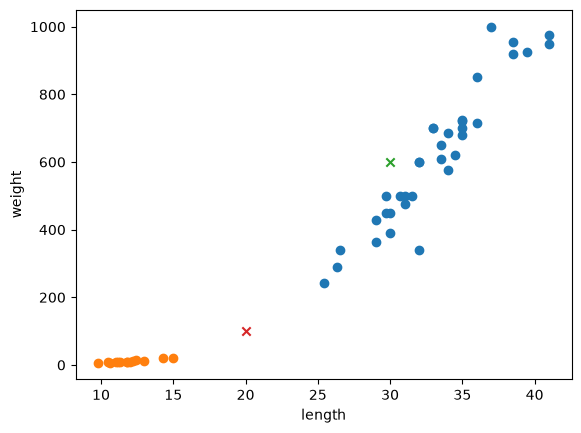

In [13]:
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)

plt.scatter([30], [600], marker='x')
plt.scatter([20], [100], marker='x')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

## KNN (K-Nearest Neighbor)

In [14]:
# 도미 데이터프레임(표)
bream_df = pd.DataFrame({
    'l': bream_length,
    'w': bream_weight,
    'c': [1] * len(bream_length)  # 카테고리1: 도미
})

# 빙어 데이터프레임(표)
smelt_df = pd.DataFrame({
    'l': smelt_length,
    'w': smelt_weight,
    'c': [0] * len(smelt_length)  # 카테고리0: 빙어
})

# 최종 데이터 프레임
df = pd.concat([bream_df, smelt_df], ignore_index=True)

# df의 앞 5개 row만 보기
df.head()

,l,w,c
0,25.4,242.0,1
1,26.3,290.0,1
2,26.5,340.0,1
3,29.0,363.0,1
4,29.0,430.0,1


In [15]:
# df 에 들어있는 데이터 (생선의 길이, 무게, 종류)를 학습시킴

from sklearn.neighbors import KNeighborsClassifier

kn =  KNeighborsClassifier()

# 원번 df의 특정 칼럼만 뽑은 것
X = df[['l', 'w']]
y = df['c']

# fit = 학습 X = 데이터, y = 답
kn.fit(X, y)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

KNeighborsClassifier()

In [8]:
kn.score(X, y)

1.0

In [16]:
kn.predict([
    [30, 600],  # 1번 케이스 -> c: 1 -> 도미
    [20, 100],  # 2번 케이스 -> c: 0 -> 빙어
])

array([1, 0])

In [17]:
# 문제 1 -> K의 개수가 커지면? (현재 전체 데이터 개수 49)
kn49 = KNeighborsClassifier(n_neighbors=49)
_ = kn49.fit(X, y)  # 무조건 도미로 판단하는 분류기
kn49.score(X, y)  # 0.74xxx -> 35/49

# 현재 도미 35, 빙어 14
kn49.predict([
    [1, 1],
    [1000, 1000]
])

array([1, 1])

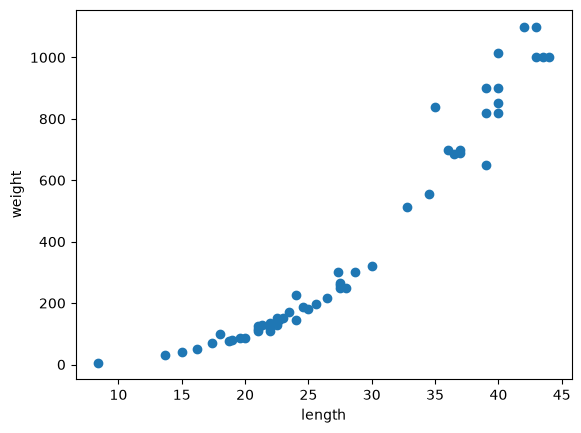

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 농어의 길이 & 무게
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])


plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(perch_length, perch_weight, random_state=42)

# X자리에는 벡터가 아닌 매트릭스가 와야함
X_train.reshape(-1, 1)   # 벡터 -> 매트리스 변환
X_test = X_test.reshape(-1, 1)


In [32]:
from sklearn.neighbors import KNeighborsClassifier

knr =  KNeighborsClassifier()
knr.fit(X_train, y_train) 

knr.score(X_test, y_test)


ValueError: Expected 2D array, got 1D array instead:
array=[19.6 22.  18.7 17.4 36.  25.  40.  39.  43.  22.  20.  22.  24.  27.5
 43.  40.  24.  21.  27.5 40.  32.8 26.5 36.5 13.7 22.7 15.  37.  35.
 28.7 23.5 39.  21.  23.  22.  44.  22.5 19.  37.  22.  25.6 42.  34.5].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [35]:
# 우리 모델이 예측한 값
test_prediction = knr.predict(X_test)

# 예측과 정답의 오차
test_prediction - y_test


NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.